# Point 3, Decision Support, Real Outcome Attribution

## Table Of Contents

- [1. The Problem And This Approach](#sec1)
- [2. Data Preparation](#sec2)
- [3. Logistic Regression On The Real Outcome](#sec3)
- [4. How Much Would These Numbers Move](#sec4)
- [5. Saving The Standardized Result](#sec5)
- [6. Takeaways](#sec6)

<a id="sec1"></a>

## 1. The Problem And This Approach

The other two notebooks in this folder both rank biomarkers by how well they predict RISK_SCORE, Point 3's own placeholder measure, one from each biomarker's current level, the other from its rate of change. Both answers are only as good as that placeholder target, a coarse combination of DIAGNOSIS and AMYLOID_STATUS stands in for a fuller risk estimate for now, so a ranking against it is a ranking against a stand in, not against what actually happened to a patient.

This notebook drops RISK_SCORE entirely and asks the same attribution question against a real recorded event instead, compute_diagnosis_worsening's own DIAGNOSIS_WORSENED_NEXT column, already used by the interval policy notebooks to check a recommended interval against what genuinely happened next, reused here as the target itself rather than as a side check. Since the target is now a genuine yes or no outcome rather than a continuous score, area under the ROC curve replaces R squared and mean absolute error as the fair way to score it, 0.5 is chance, 1.0 is a perfect ranking of who actually worsened.

This is the third of three genuinely competing approaches in this folder, level against a placeholder, speed against the same placeholder, and level against a real event. See comparison.ipynb for how the three read against each other.

In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
sys.path.append(os.path.join('..', '..', '..'))

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from util import decision_util as du

data_folder = os.path.join('..', '..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
results_path = os.path.join('..', '..', '..', 'results', 'decision_support')
os.makedirs(results_path, exist_ok=True)

<a id="sec2"></a>

## 2. Data Preparation

The cell below loads datasets/final.csv, the same table every other notebook in this folder loads, and forward fills the same seven sparse biomarkers, HIPPO_NORM, ENTORHINAL_NORM, AMYGDALA_NORM, SUMMARY_SUVR, ABETA_RATIO, TAU, and PTAU, carrying each patient's most recently known value forward to later visits.

This notebook does not build or read RISK_SCORE at all, its target is compute_diagnosis_worsening's own DIAGNOSIS_WORSENED_NEXT column below, a real recorded event rather than any placeholder or composite measure. subject_train_test_split holds out 25 percent of patients, by RID rather than by row, with random_state=42 fixed so this split matches every other approach notebook in this folder exactly.

In [2]:
data = pd.read_csv(data_path)

biomarker_cols_to_fill = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols_to_fill, id_col='RID', date_col='EXAMDATE_DX',
)

train_df, test_df = du.subject_train_test_split(data, test_fraction=0.25, random_state=42)
print(f'Train, {train_df.shape[0]} rows, {train_df.RID.nunique()} patients')
print(f'Test,  {test_df.shape[0]} rows, {test_df.RID.nunique()} patients')

Train, 10162 rows, 2832 patients
Test,  3665 rows, 945 patients


<a id="sec3"></a>

## 3. Logistic Regression On The Real Outcome

compute_diagnosis_worsening looks, for every row, at that same patient's immediately following visit, and returns DIAGNOSIS_WORSENED_NEXT, True when their real DIAGNOSIS was numerically worse there, and HAS_NEXT_VISIT, True only when a later visit genuinely exists. A patient's last observed visit has nothing after it to compare against, so rows without a next visit are dropped here, the same way the other two notebooks in this folder drop rows missing a biomarker they need.

The same eight biomarkers 1_global.ipynb uses, HIPPO_NORM, ENTORHINAL_NORM, AMYGDALA_NORM, SUMMARY_SUVR, ABETA_RATIO, TAU, PTAU, and AGE, are the inputs here too, with PTGENDER, PTEDUCAT, and PTMARRY again explicitly excluded, so this notebook's own attribution cannot be traced back to a protected attribute either. Logistic Regression with an L1 penalty is the classification twin of the Lasso baseline the other two notebooks fit, following the same 06-at, lesson 2 choice between a Logistic Regression or a Lasso model as the first, interpretable step, scored here by area under the ROC curve rather than R squared and mean absolute error, since the target is now a real yes or no event.

In [3]:
train_outcomes = du.compute_diagnosis_worsening(
    train_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
test_outcomes = du.compute_diagnosis_worsening(
    test_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)

feature_cols = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU', 'AGE',
]
train_model_data = train_outcomes[train_outcomes['HAS_NEXT_VISIT']].dropna(subset=feature_cols)
test_model_data = test_outcomes[test_outcomes['HAS_NEXT_VISIT']].dropna(subset=feature_cols)
print(f'Train, {len(train_model_data)} rows with a next visit on record and no missing biomarker')
print(f'Test,  {len(test_model_data)} rows with a next visit on record and no missing biomarker')

outcome_model, outcome_scaler = du.fit_logistic_baseline(
    train_model_data[feature_cols],
    train_model_data['DIAGNOSIS_WORSENED_NEXT'],
)

outcome_train_metrics = du.evaluate_classification(outcome_model, train_model_data[feature_cols], train_model_data['DIAGNOSIS_WORSENED_NEXT'], scaler=outcome_scaler)
outcome_test_metrics = du.evaluate_classification(outcome_model, test_model_data[feature_cols], test_model_data['DIAGNOSIS_WORSENED_NEXT'], scaler=outcome_scaler)
print(f"Train, area under the ROC curve {outcome_train_metrics['auc']:.3f}")
print(f"Test,  area under the ROC curve {outcome_test_metrics['auc']:.3f}")

Train, 1627 rows with a next visit on record and no missing biomarker
Test,  620 rows with a next visit on record and no missing biomarker
Train, area under the ROC curve 0.720
Test,  area under the ROC curve 0.619


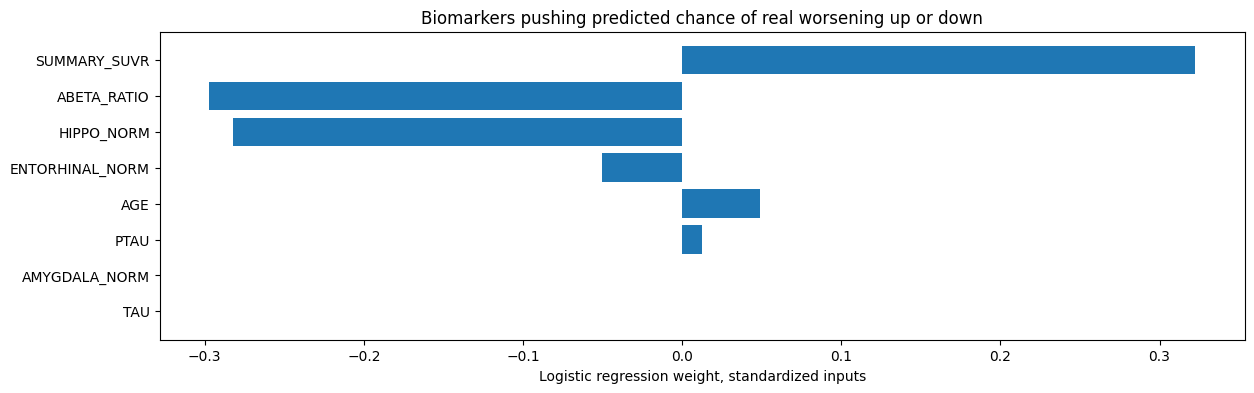

,feature,weight
0,SUMMARY_SUVR,0.322556
1,ABETA_RATIO,-0.297273
2,HIPPO_NORM,-0.282404
3,ENTORHINAL_NORM,-0.050470
4,AGE,0.048773
5,PTAU,0.012571
6,AMYGDALA_NORM,0.000000
7,TAU,0.000000


In [4]:
weights = pd.Series(outcome_model.coef_[0], index=feature_cols, name='weight')
weights = weights.reindex(weights.abs().sort_values(ascending=False).index).reset_index().rename(columns={'index': 'feature'})

plt.figure(figsize=figsize)
plt.barh(weights['feature'], weights['weight'])
plt.xlabel('Logistic regression weight, standardized inputs')
plt.title('Biomarkers pushing predicted chance of real worsening up or down')
plt.gca().invert_yaxis()
plt.show()

du.append_biomarker_ranking(results_path, '3_real_outcome', 'logistic', weights.set_index('feature')['weight'])

weights

### 3.1 How Much Would These Weights Themselves Move

Section 4 below bootstraps the area under the ROC curve by scoring the same already fitted model again on each resample, appropriate there since the question is how much the model's own accuracy would move with a different patient sample, not how much the model itself would change. A logistic weight has no such fixed point to reuse, the weight only exists once a model has actually been fit, so this subsection refits the logistic regression inside every one of 150 resamples instead, using bootstrap_attribution_weights from util/decision_util.py, the same function 1_global.ipynb's own subsection 3.2 and 2_decline.ipynb's own subsection 4.1 already use.

This notebook fits only one model here, unlike the other two risk_factors notebooks which each compare Lasso against a Random Forest and SHAP, so none of their tree count or explanation sample tradeoffs apply, a logistic fit at full cost is already fast enough for 150 resamples to finish in a few seconds.

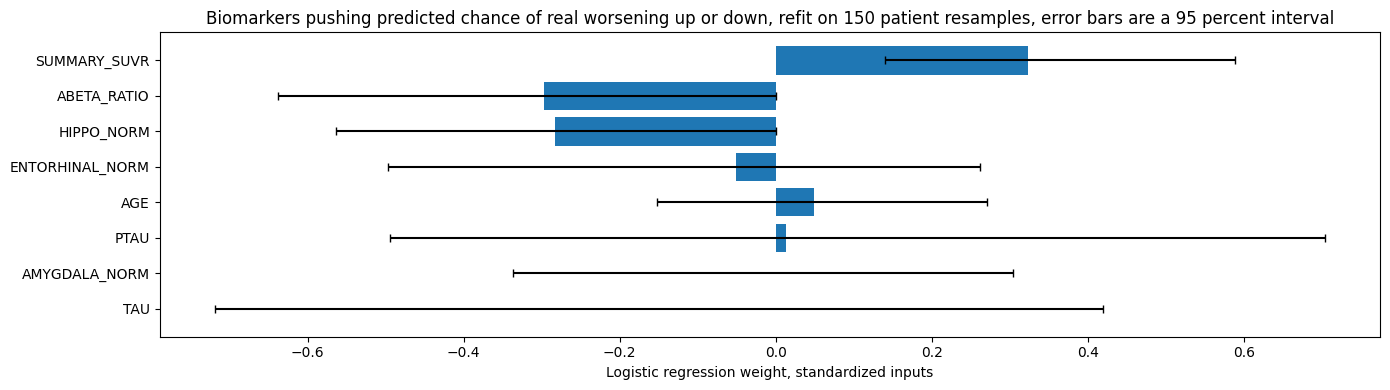

,feature,point,lower,upper,n_bootstrap
0,HIPPO_NORM,-0.282404,-0.564072,0.000000,150
1,ENTORHINAL_NORM,-0.050470,-0.496540,0.261992,150
2,AMYGDALA_NORM,0.000000,-0.336086,0.304443,150
3,SUMMARY_SUVR,0.322556,0.139404,0.588111,150
4,ABETA_RATIO,-0.297273,-0.637402,0.000000,150
5,TAU,0.000000,-0.718269,0.419094,150
6,PTAU,0.012571,-0.494902,0.702993,150
7,AGE,0.048773,-0.151769,0.269974,150


In [5]:
def outcome_fit_fn(d):
    return du.fit_logistic_baseline(d[feature_cols], d['DIAGNOSIS_WORSENED_NEXT'])

def outcome_weight_fn(fitted, d):
    model, scaler = fitted
    return pd.Series(model.coef_[0], index=feature_cols)

outcome_weight_ci = du.bootstrap_attribution_weights(train_model_data, outcome_fit_fn, outcome_weight_fn, id_col='RID', n_bootstrap=150)

ordered = outcome_weight_ci.reindex(outcome_weight_ci['point'].abs().sort_values(ascending=False).index)
err_lower = (ordered['point'] - ordered['lower']).clip(lower=0)
err_upper = (ordered['upper'] - ordered['point']).clip(lower=0)

plt.figure(figsize=figsize)
plt.barh(ordered['feature'], ordered['point'], xerr=[err_lower, err_upper], capsize=3)
plt.xlabel('Logistic regression weight, standardized inputs')
plt.title('Biomarkers pushing predicted chance of real worsening up or down, refit on 150 patient resamples, error bars are a 95 percent interval')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

outcome_weight_ci

**Read an error bar that crosses zero as this project not currently able to rule out that a biomarker's own true weight on real worsening is zero, on this particular patient sample.** Worth reading directly against 1_global.ipynb's own subsection 3.2 and 2_decline.ipynb's own subsection 4.1 for the same biomarker, three different targets, RISK_SCORE level, RISK_SCORE slope, and now real diagnosis worsening, each asking whether that biomarker's own weight survives a different patient sample on that particular target, not only whether the three targets agree on a point estimate, comparison.ipynb's own rank correlation already covers agreement between the three point estimates directly.

<a id="sec4"></a>

## 4. How Much Would These Numbers Move

The area under the ROC curve above comes from one fixed train and test split. bootstrap_ci resamples patients with replacement 400 times, a patient's own full set of rows moves together since two visits from one patient are not two independent draws, scores the same already fitted model again on each resample without ever refitting it, and reads the 2.5th and 97.5th percentile as a 95 percent interval.

Read the test interval against 0.5, not against 0, an interval that clears 0.5 says these biomarkers predict real worsening better than a coin flip would, an interval that crosses 0.5 says this run cannot yet tell the model apart from one.

Train, area under the ROC curve 0.720, 95% CI [0.660, 0.782]
Test,  area under the ROC curve 0.619, 95% CI [0.546, 0.705]


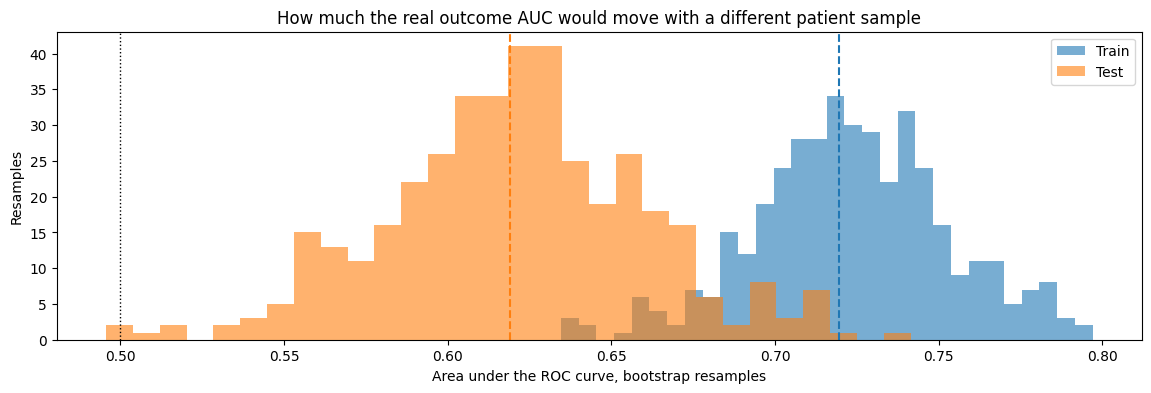

In [6]:
def make_auc_metric(model, scaler=None):
    def metric(d):
        return du.evaluate_classification(model, d[feature_cols], d['DIAGNOSIS_WORSENED_NEXT'], scaler=scaler)['auc']
    return metric

train_auc_point, train_auc_lo, train_auc_hi, train_auc_samples = du.bootstrap_ci(train_model_data, make_auc_metric(outcome_model, outcome_scaler), id_col='RID')
test_auc_point, test_auc_lo, test_auc_hi, test_auc_samples = du.bootstrap_ci(test_model_data, make_auc_metric(outcome_model, outcome_scaler), id_col='RID')

print(f'Train, area under the ROC curve {train_auc_point:.3f}, 95% CI [{train_auc_lo:.3f}, {train_auc_hi:.3f}]')
print(f'Test,  area under the ROC curve {test_auc_point:.3f}, 95% CI [{test_auc_lo:.3f}, {test_auc_hi:.3f}]')

plt.figure(figsize=figsize)
plt.hist(train_auc_samples, bins=30, alpha=0.6, label='Train')
plt.hist(test_auc_samples, bins=30, alpha=0.6, label='Test')
plt.axvline(train_auc_point, color='C0', linestyle='--')
plt.axvline(test_auc_point, color='C1', linestyle='--')
plt.axvline(0.5, color='black', linewidth=1, linestyle=':')
plt.xlabel('Area under the ROC curve, bootstrap resamples')
plt.ylabel('Resamples')
plt.title('How much the real outcome AUC would move with a different patient sample')
plt.legend()
plt.show()

<a id="sec5"></a>

## 5. Saving The Standardized Result

One row per split, appended to the shared results/decision_support/approach_comparison.csv under the same attribution group 1_global.ipynb and 2_decline.ipynb also write to, read later by comparison.ipynb alongside those. This is the one attribution row in this folder with an auc column filled in rather than r2 and mae, comparison.ipynb reads it on its own scale rather than folding it into the other two. append_approach_result is idempotent per approach and split, rerunning this notebook replaces its own two rows rather than piling up duplicates.

In [7]:
train_ci = {'auc': (train_auc_lo, train_auc_hi)}
test_ci = {'auc': (test_auc_lo, test_auc_hi)}

du.append_approach_result(
    results_path, approach='real_outcome_attribution', approach_group='attribution',
    split='train', n_rows=len(train_model_data), auc=outcome_train_metrics['auc'], ci=train_ci,
    notes=f'L1 logistic regression predicting a real recorded DIAGNOSIS_WORSENED_NEXT event from {len(feature_cols)} biomarker levels, scored by area under the ROC curve rather than r2.',
)
result_row = du.append_approach_result(
    results_path, approach='real_outcome_attribution', approach_group='attribution',
    split='test', n_rows=len(test_model_data), auc=outcome_test_metrics['auc'], ci=test_ci,
    notes=f'L1 logistic regression predicting a real recorded DIAGNOSIS_WORSENED_NEXT event from {len(feature_cols)} biomarker levels, scored by area under the ROC curve rather than r2.',
)
result_row

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
0,unconstrained,fairness_correction,train,2048,NaN,NaN,0.084095,NaN,0.344772,0.175168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
1,unconstrained,fairness_correction,test,753,NaN,NaN,0.128358,NaN,0.056403,0.211343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
2,fixed_lambda,fairness_correction,train,2048,NaN,NaN,0.029024,NaN,-0.046617,0.212322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
3,fixed_lambda,fairness_correction,test,753,NaN,NaN,0.048055,NaN,-0.290264,0.232721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
4,dual_lambda,fairness_correction,train,2048,NaN,NaN,0.042104,NaN,0.336206,0.177150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
5,dual_lambda,fairness_correction,test,753,NaN,NaN,0.122326,NaN,0.067258,0.210892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
6,pipeline_health_index,interval_policy,train,10162,59644.077200,4837.0,2.930656,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
7,pipeline_health_index,interval_policy,test,3665,21640.887371,1752.0,2.029942,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
8,hazard_logistic_core,hazard_model,train,6415,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Discrete time hazard estimator, logistic, core..."
9,hazard_logistic_core,hazard_model,test,2291,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.704754,0.782472,"Discrete time hazard estimator, logistic, core..."


<a id="sec6"></a>

## 6. Takeaways

**Read this notebook's own test AUC interval against 0.5, not against the other two notebooks' own R squared.** The two are not on the same scale, and are not meant to be forced onto one, this notebook is the one place in this folder that checks these biomarkers against a real recorded worsening event rather than against RISK_SCORE. A test interval that clears 0.5 says there is real signal here beyond what the placeholder based rankings alone could show, a real correction on top of, not a replacement for, the level and slope rankings in this folder's other two notebooks. See comparison.ipynb for the three read side by side.